# Roma Taxi EDA and Benchmark Preparation

This notebook performs scalable EDA on the CRAWDAD Roma taxi trace and prepares a benchmark-ready feature table for clustering workflows.

Goals:
1. Load and validate raw schema from the extracted trace.
2. Build spatio-temporal window features (15-min bins).
3. Run unsupervised KMeans selection and clustering.
4. Optionally compare with ExKMC on the same features.

In [7]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

os.environ.setdefault('OMP_NUM_THREADS', '1')
pd.set_option('display.max_columns', 100)

# Fast-mode defaults tuned for interactive runs under ~30 minutes.
FAST_MODE = True
MAX_ROWS = 120_000 if FAST_MODE else 500_000
STRIDE = 40 if FAST_MODE else 15
PLOT_SAMPLE_SIZE = 20_000 if FAST_MODE else 60_000
K_GRID = [2, 3, 4, 5] if FAST_MODE else list(range(2, 9))
SEED_LIST = [0, 1] if FAST_MODE else [0, 1, 2, 3, 4]
KMEANS_N_INIT = 15 if FAST_MODE else 30
ENABLE_EXKMC = False if FAST_MODE else True
EXKMC_MAX_WINDOWS = 60_000

In [2]:
repo_root = Path.cwd()
if not (repo_root / 'scripts').exists() and (repo_root.parent / 'scripts').exists():
    repo_root = repo_root.parent
elif not (repo_root / 'scripts').exists() and (repo_root.parent.parent / 'scripts').exists():
    repo_root = repo_root.parent.parent

taxi_file = repo_root / 'data' / 'roma-taxi' / 'extracted' / 'taxi_february.txt'
if not taxi_file.exists():
    raise FileNotFoundError(f'Expected extracted file not found: {taxi_file}')

print('Dataset file:', taxi_file)
print('Size (GB):', round(taxi_file.stat().st_size / (1024 ** 3), 3))

Dataset file: d:\repositories\personal\xai-spatio-temporal\data\roma-taxi\extracted\taxi_february.txt
Size (GB): 1.498


In [ ]:
line_pattern = re.compile(r'^(\d+);([^;]+);POINT\(([-0-9.]+)\s+([-0-9.]+)\)$')

def load_trace_sample(file_path, max_rows=250000, stride=25):
    rows = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i % int(stride) != 0:
                continue
            m = line_pattern.match(line.strip())
            if not m:
                continue

            driver_id = int(m.group(1))
            timestamp = m.group(2)
            lat = float(m.group(3))
            lon = float(m.group(4))
            rows.append((driver_id, timestamp, lat, lon))

            if len(rows) >= int(max_rows):
                break

    df = pd.DataFrame(rows, columns=['driver_id', 'timestamp', 'lat', 'lon'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp', 'lat', 'lon']).reset_index(drop=True)
    return df

df = load_trace_sample(taxi_file, max_rows=MAX_ROWS, stride=STRIDE)
print('FAST_MODE:', FAST_MODE)
print('Sampling config -> max_rows:', MAX_ROWS, 'stride:', STRIDE)
print('Sample shape:', df.shape)
print('Drivers in sample:', df['driver_id'].nunique())
print('Time span:', df['timestamp'].min(), 'to', df['timestamp'].max())
df.head()

Sample shape: (250000, 4)
Drivers in sample: 309
Time span: 2014-02-01 00:00:00.739166+01:00 to 2014-02-12 11:42:58.317460+01:00


,driver_id,timestamp,lat,lon
0,156,2014-02-01 00:00:00.739166+01:00,41.883672,12.487778
1,188,2014-02-01 00:00:07.820636+01:00,41.921932,12.490790
2,365,2014-02-01 00:00:13.447509+01:00,41.893828,12.475820
3,259,2014-02-01 00:00:22.748400+01:00,41.844606,12.594158
4,61,2014-02-01 00:00:28.437961+01:00,41.900312,12.472738


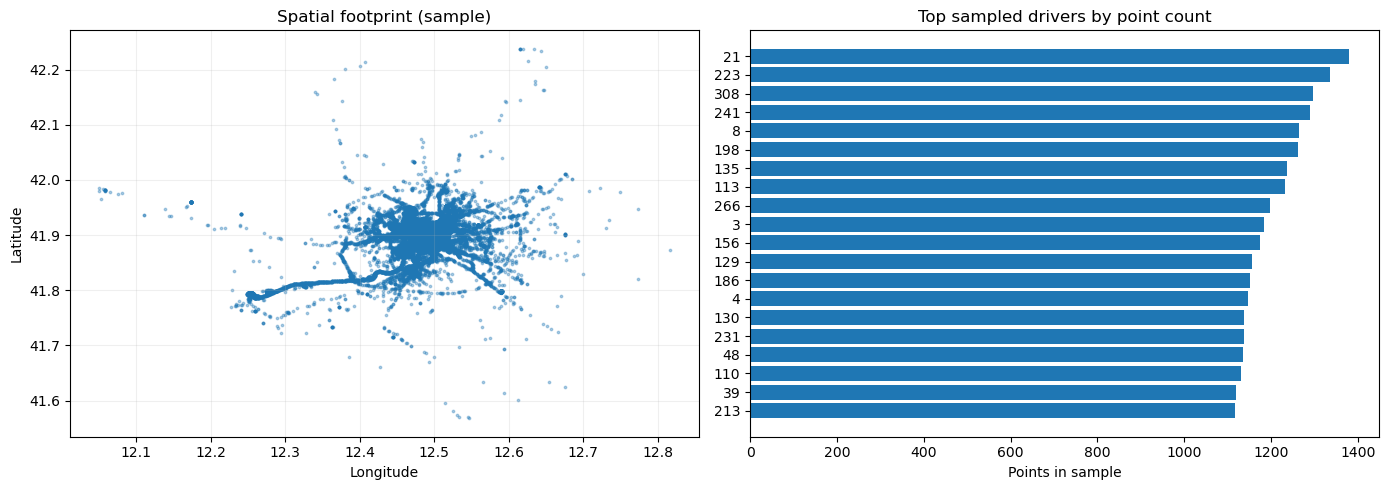

In [ ]:
sample_plot = df.sample(min(PLOT_SAMPLE_SIZE, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample_plot['lon'], sample_plot['lat'], s=3, alpha=0.35)
axes[0].set_title('Spatial footprint (sample)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(alpha=0.2)

driver_counts = df['driver_id'].value_counts().head(20).sort_values()
axes[1].barh(driver_counts.index.astype(str), driver_counts.values)
axes[1].set_title('Top sampled drivers by point count')
axes[1].set_xlabel('Points in sample')

plt.tight_layout()
plt.show()

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * r * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

df = df.sort_values(['driver_id', 'timestamp']).reset_index(drop=True)
df['prev_lat'] = df.groupby('driver_id')['lat'].shift(1)
df['prev_lon'] = df.groupby('driver_id')['lon'].shift(1)
df['prev_ts'] = df.groupby('driver_id')['timestamp'].shift(1)

delta_seconds = (df['timestamp'] - df['prev_ts']).dt.total_seconds()
distance_km = haversine_km(df['prev_lat'], df['prev_lon'], df['lat'], df['lon'])
valid_step = (delta_seconds > 0) & (delta_seconds <= 300)
df['speed_kmh'] = np.where(valid_step, distance_km / (delta_seconds / 3600.0), np.nan)

df['time_bin'] = df['timestamp'].dt.floor('15min')

window_df = df.groupby(['driver_id', 'time_bin'], as_index=False).agg(
    lat_mean=('lat', 'mean'),
    lon_mean=('lon', 'mean'),
    lat_std=('lat', 'std'),
    lon_std=('lon', 'std'),
    n_points=('lat', 'size'),
    speed_kmh_mean=('speed_kmh', 'mean'),
)

window_df[['lat_std', 'lon_std', 'speed_kmh_mean']] = window_df[['lat_std', 'lon_std', 'speed_kmh_mean']].fillna(0.0)

minute_of_day = window_df['time_bin'].dt.hour * 60 + window_df['time_bin'].dt.minute
window_df['sin_time'] = np.sin(2 * np.pi * minute_of_day / 1440.0)
window_df['cos_time'] = np.cos(2 * np.pi * minute_of_day / 1440.0)

feature_cols = [
    'lat_mean',
    'lon_mean',
    'lat_std',
    'lon_std',
    'n_points',
    'speed_kmh_mean',
    'sin_time',
    'cos_time',
]

X = StandardScaler().fit_transform(window_df[feature_cols])
print('Window feature table shape:', window_df.shape)
window_df.head()

Window feature table shape: (74478, 10)


,driver_id,time_bin,lat_mean,lon_mean,lat_std,lon_std,n_points,speed_kmh_mean,sin_time,cos_time
0,2,2014-02-01 00:00:00+01:00,41.908793,12.494212,0.001725,0.004186,3,12.293452,0.000000,1.000000
1,2,2014-02-01 00:15:00+01:00,41.896967,12.477807,0.007714,0.004172,3,13.482992,0.065403,0.997859
2,2,2014-02-01 00:30:00+01:00,41.903794,12.488273,0.000000,0.000000,1,0.000000,0.130526,0.991445
3,2,2014-02-01 00:45:00+01:00,41.906111,12.457122,0.000621,0.009328,2,20.915930,0.195090,0.980785
4,2,2014-02-01 01:00:00+01:00,41.899810,12.430989,0.000004,0.000005,3,0.007151,0.258819,0.965926


In [6]:
k_grid = K_GRID
seed_list = SEED_LIST

rows = []
for k in k_grid:
    sil_values = []
    for seed in seed_list:
        km = KMeans(n_clusters=k, random_state=seed, n_init=KMEANS_N_INIT)
        labels = km.fit_predict(X)
        sil_values.append(float(silhouette_score(X, labels)))

    rows.append({
        'k': int(k),
        'silhouette_mean': float(np.mean(sil_values)),
        'silhouette_std': float(np.std(sil_values, ddof=0)),
    })

k_eval_df = pd.DataFrame(rows).sort_values(['silhouette_mean', 'k'], ascending=[False, True]).reset_index(drop=True)
best_k = int(k_eval_df.iloc[0]['k'])

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=max(20, KMEANS_N_INIT))
window_df['kmeans_cluster'] = kmeans.fit_predict(X)

print('k selection summary:')
display(k_eval_df)
print('Selected k:', best_k)
print('Cluster sizes:')
display(window_df['kmeans_cluster'].value_counts().sort_index().to_frame('count'))

k selection summary:


,k,silhouette_mean,silhouette_std
0,2,0.487981,0.000000e+00
1,4,0.242483,5.115626e-07
2,5,0.229241,1.989940e-02
3,3,0.221237,2.206197e-06
4,6,0.215569,1.978338e-02
5,7,0.204263,1.653402e-04
6,8,0.204043,1.824695e-04


Selected k: 2
Cluster sizes:


,count
kmeans_cluster,
0,6743
1,67735


In [ ]:
if not ENABLE_EXKMC:
    print('Skipping ExKMC section because ENABLE_EXKMC=False (fast mode).')
else:
    try:
        import ExKMC.Tree as exkmc_tree_module
        from ExKMC.splitters import py_cut_finder
        exkmc_available = True
    except Exception as ex:
        exkmc_available = False
        print('ExKMC not available in this environment:', ex)

    if exkmc_available:
        def _kmeans_compat(*args, **kwargs):
            kwargs.pop('n_jobs', None)
            return KMeans(*args, **kwargs)

        exkmc_tree_module.KMeans = _kmeans_compat
        exkmc_tree_module.get_min_mistakes_cut = py_cut_finder.get_min_mistakes_cut
        exkmc_tree_module.get_min_surrogate_cut = py_cut_finder.get_min_surrogate_cut
        Tree = exkmc_tree_module.Tree

        if X.shape[0] > EXKMC_MAX_WINDOWS:
            rng = np.random.default_rng(42)
            idx = rng.choice(X.shape[0], size=EXKMC_MAX_WINDOWS, replace=False)
            X_exkmc = X[idx]
            kmeans_labels_exkmc = window_df['kmeans_cluster'].to_numpy()[idx]
            print(f'Using sampled windows for ExKMC: {X_exkmc.shape[0]} / {X.shape[0]}')
        else:
            X_exkmc = X
            kmeans_labels_exkmc = window_df['kmeans_cluster'].to_numpy()

        tree = Tree(k=best_k, max_leaves=2 * best_k, random_state=42)
        exkmc_labels = tree.fit_predict(X_exkmc)

        summary_df = pd.DataFrame([
            {
                'model': 'KMeans',
                'silhouette': float(silhouette_score(X_exkmc, kmeans_labels_exkmc)),
                'n_clusters': int(pd.Series(kmeans_labels_exkmc).nunique()),
            },
            {
                'model': 'ExKMC',
                'silhouette': float(silhouette_score(X_exkmc, exkmc_labels)),
                'n_clusters': int(pd.Series(exkmc_labels).nunique()),
            },
        ])

        ari_between_models = adjusted_rand_score(kmeans_labels_exkmc, exkmc_labels)
        print('Model comparison on identical features:')
        display(summary_df)
        print('ARI between KMeans and ExKMC partitions:', round(float(ari_between_models), 4))

        out_dir = repo_root / 'outputs'
        out_dir.mkdir(parents=True, exist_ok=True)
        plot_base = out_dir / 'exkmc_roma_taxi_tree'

        try:
            tree.plot(str(plot_base))
            print('ExKMC tree plot generated near:', str(plot_base) + '.gv.png')
        except Exception as e:
            print('tree.plot could not render in this environment:', type(e).__name__, e)
            print('Install Graphviz system binaries and add dot to PATH to enable rendering.')
    else:
        print('Skipping ExKMC section. KMeans benchmark is still complete.')

Model comparison on identical features:


,model,silhouette,n_clusters
0,KMeans,0.487981,2
1,ExKMC,0.195398,2


ARI between KMeans and ExKMC partitions: 0.0127
digraph ClusteringTree {
n_0 [label="7 <= -0.270
samples=\74478"];
n_1 [label="3 <= 1.816
samples=\36586"];
n_2 [label="6 <= 1.237
samples=\37892"];
n_3 [label="0
samples=\35349
mistakes=\4093"];
n_4 [label="1
samples=\1237
mistakes=\165"];
n_5 [label="1
samples=\31161
mistakes=\379"];
n_6 [label="0
samples=\6731
mistakes=\786"];
n_0 -> n_1;
n_0 -> n_2;
n_1 -> n_3;
n_1 -> n_4;
n_2 -> n_5;
n_2 -> n_6;
}
tree.plot could not render in this environment: ExecutableNotFound failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
Install Graphviz system binaries and add dot to PATH to enable rendering.


## Benchmark guidance

Use this Roma taxi dataset as a **real-world spatio-temporal benchmark** after (or alongside) controlled ECG baselines.

Recommended order:
1. Validate workflow stability on ECG200/ECG5000.
2. Run Roma taxi as a realism and scalability benchmark.
3. Keep the same reporting template (feature setup, k-selection, model comparison, caveats).